# Simulating Gravitational Orbits Using Numerical Methods

## Chloe Lin

**2025/02/04**

In this notebook, we are going to simulate gravitational orbits using numerical integration techniques. First, we will apply **Euler’s method** and the **velocity Verlet method** to model two body systems:
- a small mass orbiting a large fixed mass
- two bodies with similar masses orbiting their common centre of mass.

Then, we will look at more complicated problems using the **velocity Verlet method**. We will also experiment with the use of the **Fourth order Runge-Kutta Integrator** in simulating a simple two-body system, checking the conservation of energy and angular momentum throughout the simulation.

## 1. Two-Body Problems with Euler's Method

### Euler’s method 
To start off, we will use Euler’s method, a numerical integration method to solve ordinary differential equations, to do a simulation for simple gravitational orbits of **two-body systems**. In this context, it updates the position $\mathbf{r}(t)$ and velocity $\mathbf{v}(t)$ as:
$$\mathbf{r}(t+\Delta t)=\mathbf{r}(t)+\mathbf{v}(t)\Delta t$$
$$\mathbf{v}(t+\Delta t)=\mathbf{v}(t)+\mathbf{a}(t)\Delta t$$
Since the method uses extrapolation to estimate the future state, the timestep $\Delta t$ must be small enough to ensure accuracy. Therefore we will choose a time step such that the displacement per step ($\mathbf{v}\Delta t$) is much smaller than the orbital radius.

In [4]:
import numpy as np
import matplotlib.pyplot as plt

In [5]:
%matplotlib inline

### Create force function
First of all we write a function to evaluate the gravitational force on a mass, $m_1$, at a point $\mathbf{r_1}$  due to another mass, $m_2$, located at a point $\mathbf{r_2}$:
$$\mathbf{{F_1}}=\frac{Gm_1m_2}{r_{12}^3}\mathbf{r_{12}}$$
where $\mathbf{r_{12}} = \mathbf{r_2} - \mathbf{r_1}$, $\mathbf{r_{12}} = |\mathbf{r_{12}}|$

In [7]:
def force(r1,r2,m1,m2):
    """Calculate the gravitational force on mass m1 due to mass m2.
    
    Inputs:
    - r1  position vector of mass 1
    - r2  position vector of mass 2
    - m1  mass 1
    - m2  mass 2
    
    Returns:
    - gravitational force as a vector
    """
    # Find r_12 and its magnitude
    r12 = r2 - r1
    r12_mag = np.linalg.norm(r12) # Calculate orbital radius
    
    # Avoid dividing by zero if bodies overlap
    if r12_mag < 1e-12:
        return np.zeros_like(r12)

    f_on_m1 = G*m1*m2*r12 / (r12_mag**3)
    return f_on_m1

### 1.1 A small mass orbiting a large fixed mass

We will start with a simple yet less realistic orbit simulation: a small mass $m_{small}=0.0001$ orbiting a large mass $m_{large}=1.0$ fixed at the origin $(0,0)$. 

For simplicity we set the gravitational constant $G$ and the radius of orbit $r$ to 1.

#### 1.1.1 Set up initial conditions

Initially, $m_{small}$ would be placed at a point at a distance $r$ = 1 from $m_{large}$. We set this point to be $(1,0)$. For a circular orbit, the orbital speed can be calculated by simple mechanics:

$$\frac{m v^2}{r}=\frac{Gm M}{r^2}$$

Rearrange to find $v$:

$$ v = \sqrt{\frac{GM}{r}}$$

with $G = 1$, $M = 1$ and $r=1$,
$$ v = \sqrt {\frac{1\times 1}{1}} = 1$$

The velocity is tangential to the radial vector, so for $r=(1,0)$, velocity $v$ is $(0,1)$.

In [9]:
# Set up parameters
Ndim = 2     # 2D problem 
Nsteps = 10000  # Number of time steps
dt = 0.001   # Time step
G = 1        # Set gravitaional constant as 1
m_small_euler = 0.0001  # Small mass 1
m_large_euler = 1.0     # Large mass 2

# Set up storage arrays for positions and velocities
r_small_euler = np.zeros((Nsteps, Ndim))
r_large_euler = np.zeros((Nsteps, Ndim))
v_small_euler = np.zeros((Nsteps, Ndim))
v_large_euler = np.zeros((Nsteps, Ndim))

# Set up storage for energies
KE = np.zeros(Nsteps)
PE = np.zeros(Nsteps)
total_energy = np.zeros(Nsteps)
angular_momentum = np.zeros(Nsteps)

# Initial conditions: small m is placed at a distance r=1 from large m fixed at the origin
r_small_euler[0,:] = np.array((1.0, 0.0))
v_small_euler[0,:] = np.array((0.0, 1.0))  # Initial velocity of small m 
r_large_euler[0,:] = np.array([0.0, 0.0])
v_large_euler[0,:] = np.array([0.0, 0.0])

# Compute the initial energies and angular momentum for m1.
KE[0] = 0.5*m_small_euler*np.dot(v_small_euler[0,:], v_small_euler[0,:])
distance = np.linalg.norm(r_small_euler[0,:] - r_large_euler[0,:])
PE[0] = -G*m_small_euler*m_large_euler / distance
total_energy[0] = KE[0] + PE[0]
# Angular momentum in 2D: L = m_small * (x*v_y - y*v_x)
angular_momentum[0] = m_small_euler*(r_small_euler[0,0]*v_small_euler[0,1] -
                                     r_small_euler[0,1]*v_small_euler[0,0])

#### 1.1.2 Run the Euler's Update loop

In [11]:
# Euler's Method Simulation Loop
for i in range(Nsteps-1):   # We calculate r, v at i+1
    f_small_euler = force(r_small_euler[i,:], r_large_euler[i,:], m_small_euler, m_large_euler)
    a_small_euler = f_small_euler / m_small_euler  # Acceleration of m1
    
    v_small_euler[i+1,:] = v_small_euler[i,:] + dt*a_small_euler   # v at next step = v at this step + dt * dv/dt
    r_small_euler[i+1,:] = r_small_euler[i,:] + dt*v_small_euler[i,:]   # r at next step = r at this step + dt * dr/dt
    # Large m is fixed at origin
    r_large_euler[i+1,:] = r_large_euler[i,:]
    v_large_euler[i+1,:] = v_large_euler[i,:]
    
    # Calculate the energies 
    KE[i+1] = 0.5*m_small_euler*np.dot(v_small_euler[i+1,:], v_small_euler[i+1,:])  # KE = 0.5*m*v^2
    distance = np.linalg.norm(r_small_euler[i+1,:] - r_large_euler[i+1,:])   
    PE[i+1] = -G*m_small_euler*m_large_euler / distance   # PE = -G*m1*m2/r12
    total_energy[i+1] = KE[i+1] + PE[i+1]

    # Calculate angular momentum for m1 
    angular_momentum[i+1] = m_small_euler*(r_small_euler[i+1,0]*v_small_euler[i+1,1] - r_small_euler[i+1,1]*v_small_euler[i+1,0])

#### 1.1.3 Plot the orbit

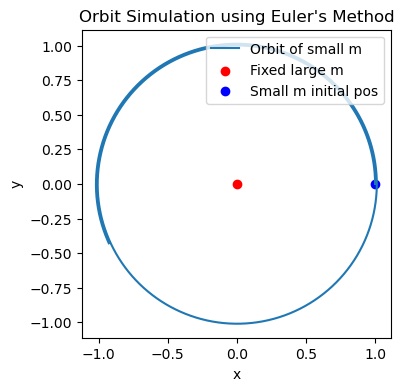

In [13]:
# Plot the orbit (x vs y)
fig = plt.figure(figsize=(4,4))
plt.plot(r_small_euler[:,0], r_small_euler[:,1], label='Orbit of small m')
plt.scatter([0], [0], color='red', label='Fixed large m')
plt.scatter(r_small_euler[0,0],[0],color='blue', label='Small m initial pos')
plt.xlabel('x')
plt.ylabel('y')
plt.title("Orbit Simulation using Euler's Method")
plt.axis('scaled')
plt.legend(loc='upper right')
plt.show()

We can see that the orbit of the small mass is not enclosed (i.e. not perfectly circular). Let's plot the total energy and angular momentum to gain a deeper insight.

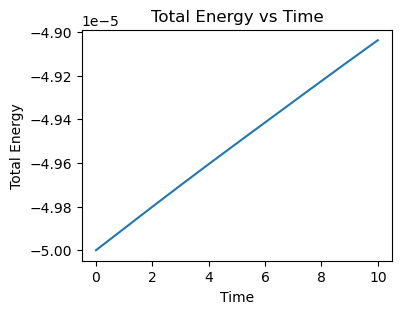

In [15]:
# Plot total energy vs time
time = np.arange(Nsteps)*dt
plt.figure(figsize=(4,3))
plt.plot(time, total_energy)
plt.xlabel('Time')
plt.ylabel('Total Energy')
plt.title("Total Energy vs Time")
plt.show()

We can see from the plot that energy increases at a constant (but slow) rate over time. This means the total energy is not very well-conserved.

Angular momentum is defined as the cross product of the position vector $\mathbf{r}$ and the momentum vector $\mathbf{p}$ (where $\mathbf{p}$ = m$\mathbf{v}$), so for a particle moving in the xy-plane, we can write:

$$\vec{L} = \vec{r} \times \vec{p}= 
\begin{vmatrix}
\hat{i} & \hat{j} & \hat{k} \\
x & y & 0 \\
v_x & v_y & 0
\end{vmatrix}
= \left( 0,\ 0,\ x\,v_y - y\,v_x \right)
$$

Since the motion is confined to the xy-plane, only the z-component is non-zero, so the angular momentum is:
$$
L_z = m \left( x\,v_y - y\,v_x \right)
$$


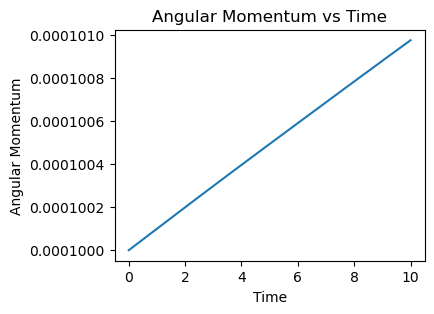

In [18]:
# Plot angular momentum vs time
plt.figure(figsize=(4,3))
plt.plot(time, angular_momentum)
plt.xlabel('Time')
plt.ylabel('Angular Momentum')
plt.title("Angular Momentum vs Time")
plt.show()

We can see from the plot that the angular momentum also increases at a constant rate over time.

Therefore, we can conclude that even for a small time step of 0.001, Euler's method is still unable to conserve energy and momentum perfectly.

**2025/02/05**: What if we use a bigger time step? How much worse will the conservation be?

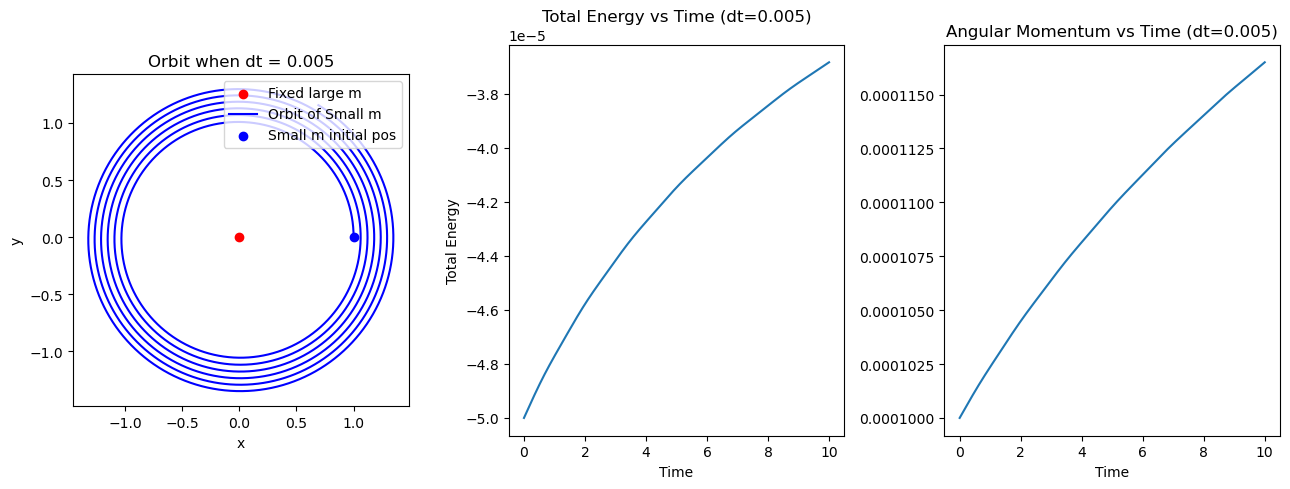

In [21]:
# Trying a bigger value for time step dt
larger_dt = 0.005

for i in range(Nsteps-1):   # We calculate r, v at i+1
    f_small_euler = force(r_small_euler[i,:], r_large_euler[i,:], m_small_euler, m_large_euler)
    a_small_euler = f_small_euler / m_small_euler  # Acceleration of small m
    # v at next step = v at this step + dt * dv/dt
    v_small_euler[i+1,:] = v_small_euler[i,:] + larger_dt*a_small_euler 
    # r at next step = r at this step + dt * dr/dt
    r_small_euler[i+1,:] = r_small_euler[i,:] + larger_dt*v_small_euler[i,:]   
    # large m is fixed at origin
    r_large_euler[i+1,:] = r_large_euler[i,:]
    v_large_euler[i+1,:] = v_large_euler[i,:]
    
    # Calculate the energies 
    KE[i+1] = 0.5*m_small_euler*np.dot(v_small_euler[i+1,:], v_small_euler[i+1,:])  # KE = 0.5*m*v^2
    distance = np.linalg.norm(r_small_euler[i+1,:] - r_large_euler[i+1,:])   
    PE[i+1] = -G*m_small_euler*m_large_euler / distance   # PE = -G*m1*m2/r12
    total_energy[i+1] = KE[i+1] + PE[i+1]

    # Calculate angular momentum for m1 
    angular_momentum[i+1] = m_small_euler*(r_small_euler[i+1,0]*v_small_euler[i+1,1] 
                                        - r_small_euler[i+1,1]*v_small_euler[i+1,0])

# Plot the orbit (x vs y), total energy and angular momentum vs time
fig1_euler = plt.figure(figsize=(13,5),tight_layout=True)
fig1_euler_1 = fig1_euler.add_subplot(1,3,1)
fig1_euler_1.scatter([0], [0], color='red', label='Fixed large m')
fig1_euler_1.plot(r_small_euler[:,0], r_small_euler[:,1], label='Orbit of Small m',color='blue')
fig1_euler_1.scatter(r_small_euler[0,0],[0],color='blue', label='Small m initial pos')
fig1_euler_1.set_xlabel('x')
fig1_euler_1.set_ylabel('y')
fig1_euler_1.set_title("Orbit when dt = 0.005")
fig1_euler_1.axis('scaled')
fig1_euler_1.legend(loc='upper right')

fig1_euler_2 = fig1_euler.add_subplot(1,3,2)
fig1_euler_2.plot(time, total_energy)
fig1_euler_2.set_xlabel('Time')
fig1_euler_2.set_ylabel('Total Energy')
fig1_euler_2.set_title("Total Energy vs Time (dt=0.005)")

fig1_euler_3 = fig1_euler.add_subplot(1,3,3)
fig1_euler_3.plot(time, angular_momentum)
fig1_euler_3.set_xlabel('Time')
fig1_euler_3.set_title("Angular Momentum vs Time (dt=0.005)")

plt.show()

The orbit drift becomes more obvious for larger dt. The small mass is now spiralling and slowly moving away from the big mass. The rate of change in total energy and angular momentum is also larger.

The orbit produced by Euler’s method is not perfectly circular, and both the total energy and angular momentum show a continuous increase over time. This behavior is expected because in Euler’s method we use the gradient at the start of the interval, which means that when we step forwards, we extrapolate. Being a first-order and non-symplectic integrator, Euler's method does not conserve energy or angular momentum accurately. The numerical errors introduced at each time step accumulate, leading to a drift in these quantities.

The choice of the time step dt is also important. A smaller dt reduces the error, but it cannot eliminate the systematic drift entirely due to the limitations of the method. 

### 1.2 Two bodies of similar masses orbiting centre of mass

**2025/02/06**

Next we are going to simulate two bodies $m_1 = 1.0$ and $m_2 = 0.5$ that move in orbit around their centre of mass $\mathbf{r}_{COM}$. 

#### 1.2.1 Initial conditions

The two bodies are initially aligned along the x‑axis, with their center of mass lying at the origin and the separation between them $|r_1-r_2|$ set to 1. The initial positions are determined by solving :

$$\mathbf{r}_{COM} = \frac{m_1 \mathbf{r}_1+m_2 \mathbf{r}_2}{m_1+m_2} = 0$$
$$|r_1-r_2| = 1$$

This yields:
$$r_1 = \frac{m_2}{m_1+m_2} = \frac{1}{3}$$
$$r_2 = r_1-1 = -\frac{2}{3}$$


The initial velocities follow from simple mechanics exactly as in the first case, except in this case, for the first body $m_1 v_1^2/r_1=Gm_1 m_2/r_{12}^2$ with $r_1$ the distance from the first body to the origin and $r_{12}$ the distance between the two bodies $|r_1-r_2|$, which is set to be 1. This is equivalent for the second body: $m_2 v_2^2/r_2=Gm_1 m_2/r_{12}^2$.

In [25]:
# Set up new parameters
Ndim = 2     # 2D problem 
Nsteps = 10000  # Number of time steps
dt = 0.001   # Time step
G = 1        # Set gravitaional constant to 1
m1_euler = 1.0     # Mass 1
m2_euler = 0.5     # Mass 2

# Set up storage arrays for positions and velocities
r1_euler = np.zeros((Nsteps, Ndim))
r2_euler = np.zeros((Nsteps, Ndim))
v1_euler = np.zeros((Nsteps, Ndim))
v2_euler = np.zeros((Nsteps, Ndim))

# Set up storage for energies
KE = np.zeros(Nsteps)
PE = np.zeros(Nsteps)
total_energy = np.zeros(Nsteps)
angular_momentum = np.zeros(Nsteps)

In [26]:
# Initial x-coordinates 
x1_init = m2_euler / (m1_euler + m2_euler)   
x2_init = x1_init - 1                         
# Initial position arrays
r1_euler[0,:] = np.array([x1_init, 0.0])      
r2_euler[0,:] = np.array([x2_init, 0.0])      
# Initial speeds
v1_speed = np.sqrt(G*m2_euler*abs(x1_init))
v2_speed = np.sqrt(G*m1_euler*abs(x2_init))
# Initial velocity arrays
v1_euler[0, :] = np.array([0.0, v1_speed])    
v2_euler[0, :] = np.array([0.0, -v2_speed])   

# Compute initial energies and angular momentum
# Kinetic energy:  KE = 1/2 mv^2 
KE[0] = (0.5 * m1_euler * np.dot(v1_euler[0], v1_euler[0]) + 
         0.5 * m2_euler * np.dot(v2_euler[0], v2_euler[0]))

# Potential energy:  U  = -G m1 m2 / r12, where r12 is the separation.
separation = np.linalg.norm(r1_euler[0] - r2_euler[0])
PE[0] = -G * m1_euler * m2_euler / separation

total_energy[0] = KE[0] + PE[0]

# Angular momentum: L_z = m(x v_y - y v_x)
angular_momentum[0] = (m1_euler * (r1_euler[0, 0]*v1_euler[0, 1] - r1_euler[0, 1]*v1_euler[0, 0]) +
                       m2_euler * (r2_euler[0, 0]*v2_euler[0, 1] - r2_euler[0, 1]*v2_euler[0, 0]))


#### 1.2.2 Run the Euler's Update loop

In [28]:
# Euler's Method Simulation Loop
for i in range(Nsteps-1):   # We calculate r, v at i+1
    f1_euler = force(r1_euler[i,:], r2_euler[i,:], m1_euler, m2_euler)
    a1_euler = f1_euler / m1_euler  # Acceleration of m1
    f2_euler = force(r2_euler[i,:], r1_euler[i,:], m2_euler, m1_euler)
    a2_euler = f2_euler / m2_euler  # Acceleration of m2

    # v at next step = v at this step + dt * dv/dt
    v1_euler[i+1,:] = v1_euler[i,:] + dt*a1_euler 
    v2_euler[i+1,:] = v2_euler[i,:] + dt*a2_euler
    # r at next step = r at this step + dt * dr/dt
    r1_euler[i+1,:] = r1_euler[i,:] + dt*v1_euler[i,:] 
    r2_euler[i+1,:] = r2_euler[i,:] + dt*v2_euler[i,:]   
    
    # Store energies
    KE[i+1] = (0.5 * m1_euler * np.dot(v1_euler[i+1], v1_euler[i+1]) + 
               0.5 * m2_euler * np.dot(v2_euler[i+1], v2_euler[i+1]))
    separation = np.linalg.norm(r1_euler[i+1] - r2_euler[i+1])
    PE[i+1] = -G * m1_euler * m2_euler / separation
    total_energy[i+1] = KE[i+1] + PE[i+1]
    # Angular momentum
    angular_momentum[i+1] = (m1_euler * (r1_euler[i+1, 0]*v1_euler[i+1, 1] - r1_euler[i+1, 1]*v1_euler[i+1, 0]) +
                             m2_euler * (r2_euler[i+1, 0]*v2_euler[i+1, 1] - r2_euler[i+1, 1]*v2_euler[i+1, 0]))

#### 1.2.3 Plot the orbit, energies and angular momentum

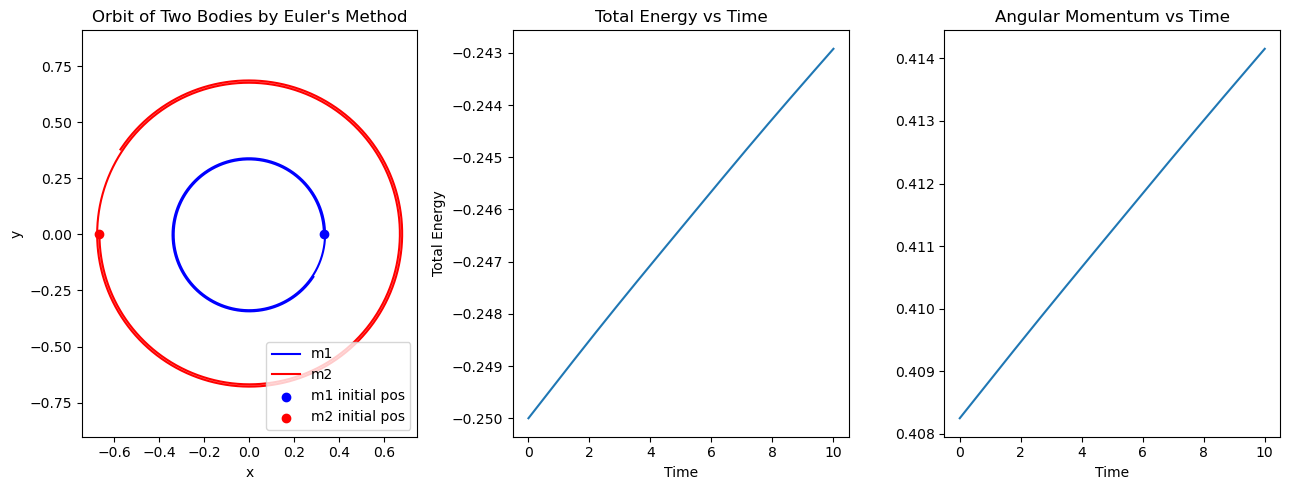

In [30]:
# Plot the orbit (x vs y) and total energy and angular momentum vs time
fig2_euler = plt.figure(figsize=(13,5),tight_layout=True)
fig2_euler_1 = fig2_euler.add_subplot(1,3,1)
fig2_euler_1.plot(r1_euler[:,0], r1_euler[:,1], label='m1',color='blue')
fig2_euler_1.plot(r2_euler[:,0], r2_euler[:,1], label='m2',color='red')
fig2_euler_1.scatter(x1_init,[0], label='m1 initial pos',color='blue')
fig2_euler_1.scatter(x2_init,[0], label='m2 initial pos',color='red')
fig2_euler_1.set_xlabel('x')
fig2_euler_1.set_ylabel('y')
fig2_euler_1.set_title("Orbit of Two Bodies by Euler's Method")
fig2_euler_1.axis('equal')
fig2_euler_1.legend()

fig2_euler_2 = fig2_euler.add_subplot(1,3,2)
fig2_euler_2.plot(time, total_energy)
fig2_euler_2.set_xlabel('Time')
fig2_euler_2.set_ylabel('Total Energy')
fig2_euler_2.set_title("Total Energy vs Time")

fig2_euler_3 = fig2_euler.add_subplot(1,3,3)
fig2_euler_3.plot(time, angular_momentum)
fig2_euler_3.set_xlabel('Time')
fig2_euler_3.set_title("Angular Momentum vs Time")

plt.show()

The plots look exactly as we would expect from Euler's method with a more complicated orbit system: 
- orbits are not enclosed
- change of total energy is much more significant - energy is conserved poorly
- change of total angular momentum over time is poorly conserved as well
  
This is again due to the nature of Euler integrators. Decreasing the time step might reduce some error, but wouldn't eliminate all the errors.

## 2. Simulating orbitals using the velocity Verlet Method 

**2025/02/07**

In this part , we are going to do the simulations using a more reliable integrator: the velocity Verlet integrator. The equations for updating position and velocity for a given body are:

$$x(t+\Delta t) = x(t)+\Delta tv(t)+\Delta t^2 \frac{F(t)}{2m}$$
$$v(t+\Delta t)=v(t)+\Delta t \frac{F(t)+F(t+\Delta t)}{2m}$$

Again we are starting with the simpler system: a small mass orbiting a large fixed mass.

### 2.1 A small mass orbiting a large fixed mass

#### 2.1.1 Initial conditions

The initial conditions are the same as in section 1.1.

In [34]:
# Set up parameters
Ndim_verlet = 2            # 2D problem 
Nsteps_verlet = 20000      # Number of time steps for several orbital periods
dt_verlet = 0.001          # Time step
G = 1                      # Set gravitaional constant as 1
m_small_verlet = 0.0001    # Small mass 1
m_large_verlet = 1.0       # Large mass 2

# Set up storage arrays for positions and velocities
r_small_verlet = np.zeros((Nsteps_verlet, Ndim_verlet))
r_large_verlet = np.zeros((Nsteps_verlet, Ndim_verlet))
v_small_verlet = np.zeros((Nsteps_verlet, Ndim_verlet))
v_large_verlet = np.zeros((Nsteps_verlet, Ndim_verlet))

# Storage for energies and angular momentum
KE_verlet = np.zeros(Nsteps_verlet)
PE_verlet = np.zeros(Nsteps_verlet)
total_energy_verlet = np.zeros(Nsteps_verlet)
angular_momentum_verlet = np.zeros(Nsteps_verlet)

# Initial conditions: small m is placed at a distance r=1 from large m fixed at the origin
r_small_verlet[0,:] = np.array((1.0, 0.0))
# For a circular orbit, the orbital speed is v = sqrt(G * large m/r).
# With G=1, large m=1, and r=1, v = 1.
# The velocity must be perpendicular to the radial vector.
# For r=(1,0), a perpendicular vector is (0,1).
v_small_verlet[0,:] = np.array((0.0, 1.0))  # Initial velocity of small m 
r_large_verlet[0,:] = np.array([0.0, 0.0])
v_large_verlet[0,:] = np.array([0.0, 0.0])

# Compute the initial energies and angular momentum for m1.
KE_verlet[0] = 0.5*m_small_verlet*np.dot(v_small_verlet[0,:], v_small_verlet[0,:])
distance = np.linalg.norm(r_small_verlet[0,:] - r_large_verlet[0,:])
PE_verlet[0] = -G*m_small_verlet*m_large_verlet / distance
total_energy_verlet[0] = KE_verlet[0] + PE_verlet[0]
# Angular momentum in 2D: L = m_small * (x*v_y - y*v_x)
angular_momentum_verlet[0] = m_small_verlet*(r_small_verlet[0,0]*v_small_verlet[0,1] - 
                                             r_small_verlet[0,1]*v_small_verlet[0,0])

#### 2.1.2 Propagate forward in time using the velocity Verlet method

In [36]:
# Velocity Verlet Method loop
for i in range(Nsteps_verlet - 1):
    # Find forces on small mass at this timestep
    f_small_verlet = force(r_small_verlet[i,:], r_large_verlet[i,:], m_small_verlet, m_large_verlet)
    # Update position using velocity Verlet
    r_small_verlet[i+1] = (r_small_verlet[i] + v_small_verlet[i]*dt_verlet + 
                           0.5*(f_small_verlet/m_small_verlet)*dt_verlet**2)
    # Find force at new timestep 
    f_small_verlet_new = force(r_small_verlet[i+1], r_large_verlet[i+1], m_small_verlet, m_large_verlet) 
    # Update velocity using velocity Verlet
    v_small_verlet[i+1] = v_small_verlet[i] + 0.5*((f_small_verlet/m_small_verlet) +
                                                   (f_small_verlet_new/m_small_verlet))*dt_verlet
    
    # Calculate the energies 
    KE_verlet[i+1] = 0.5*m_small_verlet*np.dot(v_small_verlet[i+1,:], v_small_verlet[i+1,:])  # KE = 0.5*m*v^2
    distance = np.linalg.norm(r_small_verlet[i+1,:] - r_large_verlet[i+1,:])   
    PE_verlet[i+1] = -G*m_small_verlet*m_large_verlet / distance   # PE = -G*m1*m2/r12
    total_energy_verlet[i+1] = KE_verlet[i+1] + PE_verlet[i+1]

    # Calculate angular momentum for small m 
    angular_momentum_verlet[i+1] = m_small_verlet*(r_small_verlet[i+1,0]*v_small_verlet[i+1,1] - 
                                                   r_small_verlet[i+1,1]*v_small_verlet[i+1,0])

#### 2.1.3 Plot orbit, energies and angular momentum

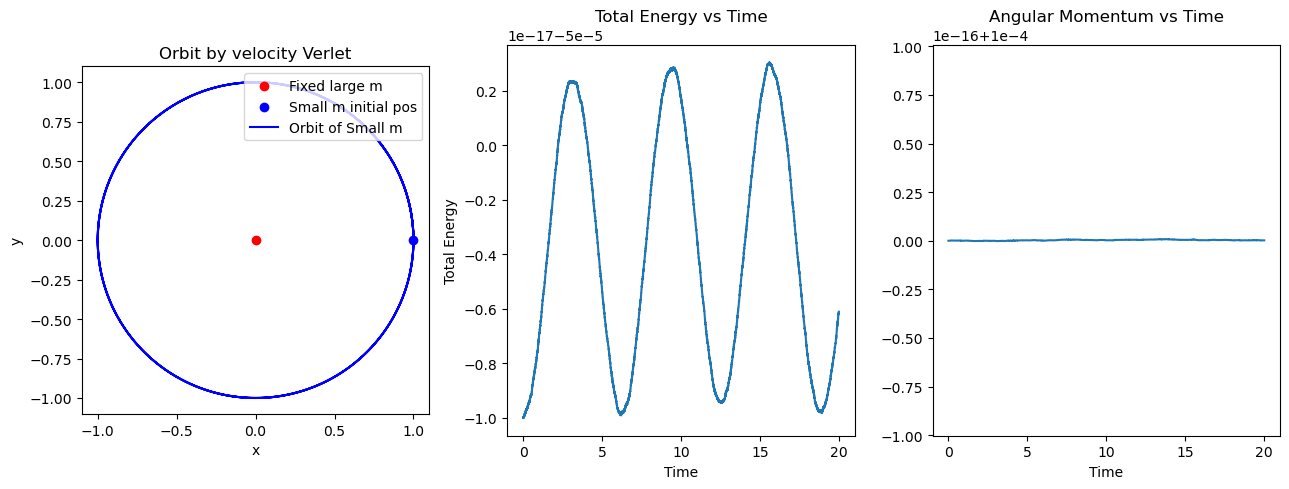

In [38]:
# Plot the orbit (x vs y) and total energy and angular momentum vs time
fig1_verlet = plt.figure(figsize=(13,5),tight_layout=True)
fig1_verlet_1 = fig1_verlet.add_subplot(1,3,1)
fig1_verlet_1.scatter([0], [0], color='red', label='Fixed large m')
fig1_verlet_1.scatter(r_small_verlet[0,0], [0], color='blue', label='Small m initial pos')
fig1_verlet_1.plot(r_small_verlet[:,0], r_small_verlet[:,1], label='Orbit of Small m',color='blue')
fig1_verlet_1.set_xlabel('x')
fig1_verlet_1.set_ylabel('y')
fig1_verlet_1.set_title("Orbit by velocity Verlet")
fig1_verlet_1.axis('scaled')
fig1_verlet_1.legend(loc='upper right')

time_verlet = np.arange(Nsteps_verlet)*dt_verlet
fig1_verlet_2 = fig1_verlet.add_subplot(1,3,2)
fig1_verlet_2.plot(time_verlet, total_energy_verlet)
fig1_verlet_2.set_xlabel('Time')
fig1_verlet_2.set_ylabel('Total Energy')
fig1_verlet_2.set_title("Total Energy vs Time")

fig1_verlet_3 = fig1_verlet.add_subplot(1,3,3)
fig1_verlet_3.plot(time_verlet, angular_momentum_verlet)
fig1_verlet_3.set_xlabel('Time')
fig1_verlet_3.set_title("Angular Momentum vs Time")

plt.show()

#### 2.1.3 Observation and Interpretation
- orbit looks perfectly circular and enclosed - accurate simulation of the orbit
- total energy oscillates, but between two extremly close values
- angular momentum remains 0 
- energy and angular momentum are much better conserved than Euler's method

### 2.2 Two bodies orbiting centre of mass

#### 2.2.1 Initial conditions
The initial conditions are the same as in section 1.2.

In [41]:
# Set up parameters
Ndim_verlet = 2           # 2D problem
Nsteps_verlet = 20000     # Number of time steps for several orbital periods
dt_verlet = 0.001         # Time step
G = 1.0                   # Gravitational constant
m1_verlet = 1.0           # Mass of body 1
m2_verlet = 0.5           # Mass of body 2

# Storage for positions and velocities 
r1_verlet = np.zeros((Nsteps_verlet, Ndim_verlet))
r2_verlet = np.zeros((Nsteps_verlet, Ndim_verlet))
v1_verlet = np.zeros((Nsteps_verlet, Ndim_verlet))
v2_verlet = np.zeros((Nsteps_verlet, Ndim_verlet))

# Storage for energies and angular momentum
KE_verlet = np.zeros(Nsteps_verlet)
PE_verlet = np.zeros(Nsteps_verlet)
total_energy_verlet = np.zeros(Nsteps_verlet)
angular_momentum_verlet = np.zeros(Nsteps_verlet)

# Initial positions 
x1_init = m2_verlet / (m1_verlet + m2_verlet)   # Positive initial x-coordinate
x2_init = x1_init - 1                           # Negative initial x-coordinate
r1_verlet[0,:] = np.array([x1_init, 0.0])       # Initial position array of m1 on the x-axis
r2_verlet[0,:] = np.array([x2_init, 0.0])       # Initial position array of m2 on the x-axis
# Initial velocities
v1_speed = np.sqrt(G*m2_verlet*abs(x1_init))
v2_speed = np.sqrt(G*m1_verlet*abs(x2_init))
v1_verlet[0, :] = np.array([0.0, v1_speed])    # Initial velocity array of m1
v2_verlet[0, :] = np.array([0.0, -v2_speed])   # Initial velocity array of m2

# Compute initial energies and angular momentum
# Kinetic energy:  KE = 1/2 mv^2 
KE_verlet[0] = (0.5 * m1_verlet * np.dot(v1_verlet[0], v1_verlet[0]) + 
                0.5 * m2_verlet * np.dot(v2_verlet[0], v2_verlet[0]))
# Potential energy:  U  = -G m1 m2 / r12, where r12 is the separation.
separation_verlet = np.linalg.norm(r1_verlet[0] - r2_verlet[0])
PE_verlet[0] = -G * m1_verlet * m2_verlet / separation_verlet
total_energy_verlet[0] = KE_verlet[0] + PE_verlet[0]

# Angular momentum: L_z = m(x v_y - y v_x)
angular_momentum_verlet[0] = (m1_verlet * (r1_verlet[0, 0]*v1_verlet[0, 1] - r1_verlet[0, 1]*v1_verlet[0, 0]) +
                              m2_verlet * (r2_verlet[0, 0]*v2_verlet[0, 1] - r2_verlet[0, 1]*v2_verlet[0, 0]))

#### 2.2.2 Propagate forward in time using the velocity Verlet method

In [43]:
# Velocity Verlet Method loop
for i in range(Nsteps_verlet - 1):
    # Find forces on masses at this timestep
    f1_verlet = force(r1_verlet[i,:], r2_verlet[i,:], m1_verlet, m2_verlet)
    f2_verlet = -f1_verlet  # Gravitational force on m2 by m1 has same magnitude but opposite directions of force on m1 by m2
    # Update positions using velocity Verlet
    r1_verlet[i+1] = r1_verlet[i] + v1_verlet[i]*dt_verlet + 0.5*(f1_verlet/m1_verlet)*dt_verlet**2
    r2_verlet[i+1] = r2_verlet[i] + v2_verlet[i]*dt_verlet + 0.5*(f2_verlet/m2_verlet)*dt_verlet**2
    # Find forces at new timestep 
    f1_verlet_new = force(r1_verlet[i+1], r2_verlet[i+1], m1_verlet, m2_verlet)
    f2_verlet_new = -f1_verlet_new 
    # Update velocities using velocity Verlet
    v1_verlet[i+1] = v1_verlet[i] + 0.5*((f1_verlet/m1_verlet) + (f1_verlet_new/m1_verlet))*dt_verlet
    v2_verlet[i+1] = v2_verlet[i] + 0.5*((f2_verlet/m2_verlet) + (f2_verlet_new/m2_verlet))*dt_verlet
    # Store energies
    KE_verlet[i+1] = (0.5 * m1_verlet * np.dot(v1_verlet[i+1], v1_verlet[i+1]) + 
                      0.5 * m2_verlet * np.dot(v2_verlet[i+1], v2_verlet[i+1]))
    separation_verlet = np.linalg.norm(r1_verlet[i+1] - r2_verlet[i+1])
    PE_verlet[i+1] = -G * m1_verlet * m2_verlet / separation_verlet
    total_energy_verlet[i+1] = KE_verlet[i+1] + PE_verlet[i+1]
    # Angular momentum
    angular_momentum_verlet[i+1] = (m1_verlet * (r1_verlet[i+1, 0]*v1_verlet[i+1, 1] - r1_verlet[i+1, 1]*v1_verlet[i+1, 0]) +
                                    m2_verlet * (r2_verlet[i+1, 0]*v2_verlet[i+1, 1] - r2_verlet[i+1, 1]*v2_verlet[i+1, 0]))

#### 2.2.3 Plot orbit, total energy and angular momentum

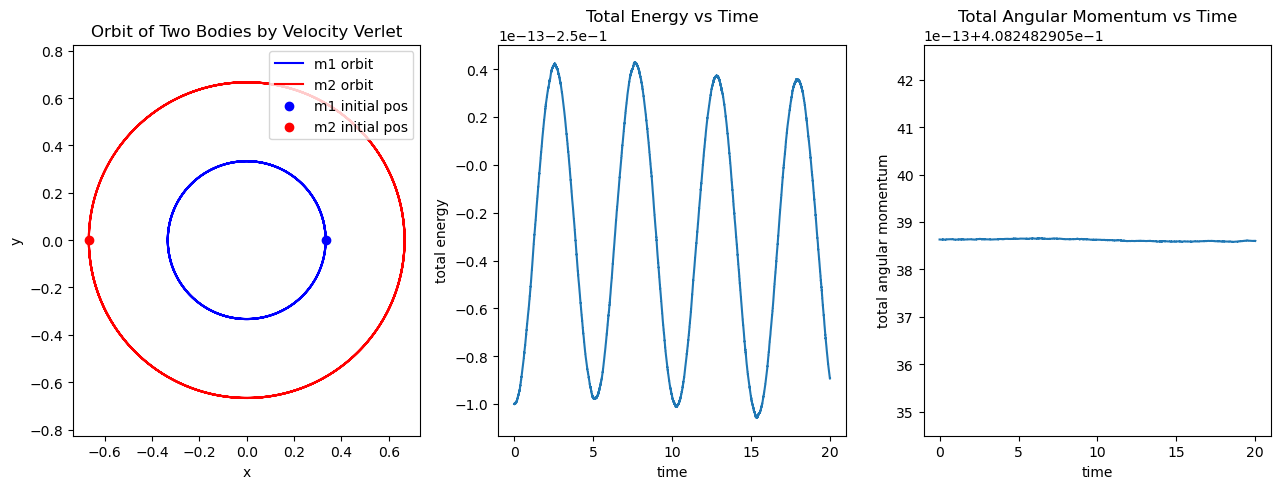

In [45]:
# Plot the orbit (x vs y) and total energy and angular momentum vs time
fig2_verlet = plt.figure(figsize=(13,5),tight_layout=True)
fig2_verlet_1 = fig2_verlet.add_subplot(1,3,1)
fig2_verlet_1.plot(r1_verlet[:,0], r1_verlet[:,1], label='m1 orbit',color='blue')
fig2_verlet_1.plot(r2_verlet[:,0], r2_verlet[:,1], label='m2 orbit',color='red')
fig2_verlet_1.scatter(x1_init,[0], label='m1 initial pos',color='blue')
fig2_verlet_1.scatter(x2_init,[0], label='m2 initial pos',color='red')
fig2_verlet_1.set_xlabel('x')
fig2_verlet_1.set_ylabel('y')
fig2_verlet_1.set_title("Orbit of Two Bodies by Velocity Verlet")
fig2_verlet_1.axis('equal')
fig2_verlet_1.legend(loc='upper right')

time_verlet = np.arange(Nsteps_verlet)*dt_verlet
fig2_verlet_2 = fig2_verlet.add_subplot(1,3,2)
fig2_verlet_2.plot(time_verlet, total_energy_verlet)
fig2_verlet_2.set_xlabel('time')
fig2_verlet_2.set_ylabel('total energy')
fig2_verlet_2.set_title("Total Energy vs Time")

fig2_verlet_3 = fig2_verlet.add_subplot(1,3,3)
fig2_verlet_3.plot(time_verlet, angular_momentum_verlet)
fig2_verlet_3.set_xlabel('time')
fig2_verlet_3.set_ylabel('total angular momentum')
fig2_verlet_3.set_title("Total Angular Momentum vs Time")

plt.show()

#### 2.2.4 Observation and Interpretation

Both m1 and m2 have perfectly circular and enclosed orbits. The total energy oscillates between extremely small values over time, meaning total energy is significantly conserved. The total angular momentum plot is almost a straight line, meaning angular momentum is also conserved in this method.

#### 2.2.5 Conclusion on the velocity Verlet method

From the plots we can conclude that the velocity Verlet is significantly better than Euler's method at conserving energy and angular momentum for the same time step. One of the reason is that we no longer extrapolate in the update algorithm.

## 3. Simulating Sun-Planet-Moon systems using Velocity Verlet

**2025/02/20**

Now we will consider a **three body problem**, which is a more challenging problem to initialise and propagate. We will use a system with a star, a planet and a moon, with masses:

$m_1 (star)=1$,
$m_2 (planet) =3×10^{-6}$ and 
$m_3 (moon) =3.6×10^{-8}$ (again with $G=1$). 

We approximate the orbit by first considering the motion between the star and the centre of mass of the planet-moon pair. We combine $m_2$ and $m_3$ to give $m_{2+3}$ and locate $m_{2+3}$ at the centre of mass of $m_2$ and $m_3$. Then $m_1$ and $m_{2+3}$ will orbit the centre of mass of the entire system $\mathbf{r}_{COM}$, which would be placed at the origin $(0,0)$. We also want the bodies to be aligned along the x-axis. 

We can calculate the centre of mass of the whole system $\mathbf{r}_{COM}$ by using the same approach to calculate the centre of mass as in the Two-body simulation, only changing $m_2$ to  $m_{23}$:

$$\mathbf{r}_{COM} = \frac{m_1 \mathbf{r}_1+m_{2+3} \mathbf{r}_{2+3}}{m_1+m_{2+3}} = 0$$
$$ |\mathbf{r}_1 - \mathbf{r}_{2+3}| = R= 1$$
where $R$ is the distance from star to planet-moon pair (we set it to 1) and $\mathbf{r}_{2+3}$ is the position of the centre of mass of the planet-moon pair.

This yields:
$$r_1 = \frac{m_{2+3}}{m_1+m_{2+3}} $$
$$r_{2+3} = r_1+1 $$

Initial velocities are calculated as follows: 

$$\frac {m_1 v_1^2}{r_1}=\frac{Gm_1 m_{2+3}}{R^2}$$
$$ v_1 = \sqrt {G m_{2+3}r_1}$$
$$\frac {m_{2+3} v_{2+3}^2}{r_{2+3}}=\frac{Gm_1 m_{2+3}}{R^2}$$
$$ v_{2+3} = \sqrt {G m_1 r_{2+3}}$$

The initial conditions of the planet-moon orbit can be calculated using the same method:

$$\mathbf{r}_{2+3} = \frac{m_2 \mathbf{r}_2+m_3 \mathbf{r}_3}{m_2+m_3} $$
$$ |\mathbf{r}_2 - \mathbf{r}_3| = r_{23} = 0.0025$$

where $r_{23}$ is the distance between the planet and the moon (which is set to be 0.0025).

This yields:

$$r_2 = r_{2+3} + \frac {m_3 r_{23}}{m_2 +m_3} $$ 
$$r_3 = r_{2+3} - \frac {m_2 r_{23}}{m_2 +m_3} $$

Initial velocities in the planet-moon subsystem are derived as follows: 

$$\frac {m_2 v_{2local}^2}{r_{2local}}=\frac{Gm_2 m_3}{r_{23}^2}$$
$$ v_{2local} = \frac{\sqrt {G m_3r_{2local}}}{r_{23}}$$
$$\frac {m_3 v_{3local}^2}{r_{3local}}=\frac{Gm_2 m_3}{r_{23}^2}$$
$$ v_{3local} = \frac {\sqrt {G m_2 r_{3local}}}{r_{23}}$$

where $r_{2local}$ and and $r_{3local}$ are positions of $m_2$ and $m_3$ relative to the centre of mass of the subsystem. 

Overall, the velocities of the planet and the moon would equal to the sum of $v_{2+3}$ and their local velocities in the subsystem:

$$v_2 = v_{2+3} + v_{2local}$$
$$v_3 = v_{2+3} + v_{3local}$$

Again we will use the velocity Verlet integrator to update positions and velocities:

$$x(t+\Delta t) = x(t)+\Delta tv(t)+\Delta t^2 \frac{F(t)}{2m}$$
$$v(t+\Delta t)=v(t)+\Delta t \frac{F(t)+F(t+\Delta t)}{2m}$$


In [48]:
# Set up new parameters
Ndim_verlet = 2           # 2D problem
Nsteps_verlet = 20000     # Number of time steps for several orbital periods
dt_verlet = 0.001         # Time step
G = 1.0                   # Gravitational constant
planet_moon_sep = 0.0025  # Distance between planet and moon
m_star_verlet = 1.0       # Mass of the star
m_planet_verlet = 3e-6    # Mass of the planet
m_moon_verlet = 3.6e-8    # Mass of the moon

# Storage for positions and velocities for all three bodies
r_star_verlet = np.zeros((Nsteps_verlet, Ndim_verlet))
r_planet_verlet = np.zeros((Nsteps_verlet, Ndim_verlet))
r_moon_verlet = np.zeros((Nsteps_verlet, Ndim_verlet))
v_star_verlet = np.zeros((Nsteps_verlet, Ndim_verlet))
v_planet_verlet = np.zeros((Nsteps_verlet, Ndim_verlet))
v_moon_verlet = np.zeros((Nsteps_verlet, Ndim_verlet))

# Storage for energies and angular momentum for all three bodies
KE_star_verlet = np.zeros(Nsteps_verlet)
KE_planet_verlet = np.zeros(Nsteps_verlet)
KE_moon_verlet = np.zeros(Nsteps_verlet)
KE_verlet = np.zeros(Nsteps_verlet)
PE_star_verlet = np.zeros(Nsteps_verlet)
PE_planet_verlet = np.zeros(Nsteps_verlet)
PE_moon_verlet = np.zeros(Nsteps_verlet)
PE_verlet = np.zeros(Nsteps_verlet)
total_energy_verlet = np.zeros(Nsteps_verlet)
angular_momentum_star_verlet = np.zeros(Nsteps_verlet)
angular_momentum_planet_verlet = np.zeros(Nsteps_verlet)
angular_momentum_moon_verlet = np.zeros(Nsteps_verlet)
angular_momentum_verlet = np.zeros(Nsteps_verlet)

In [49]:
# Initial x coordinates
x_star_init = m_planet_verlet + m_moon_verlet / (m_star_verlet + m_planet_verlet + m_moon_verlet)   
com_init = x_star_init + 1                                  
x_planet_init = com_init + m_moon_verlet*planet_moon_sep/ (m_planet_verlet + m_moon_verlet)  
x_moon_init = com_init - m_planet_verlet*planet_moon_sep/ (m_planet_verlet + m_moon_verlet)  
# Initial position array on the x-axis
r_star_verlet[0,:] = np.array([x_star_init, 0.0])           
r_planet_verlet[0,:] = np.array([x_planet_init, 0.0])       
r_moon_verlet[0,:] = np.array([x_moon_init, 0.0])           

# Initial speeds
v_star_speed = np.sqrt(G*(m_planet_verlet+m_moon_verlet)*abs(x_star_init))
v_planet_speed = (np.sqrt(G*m_star_verlet*np.abs(com_init)) +
                  np.sqrt(G*m_moon_verlet*np.abs(x_planet_init-com_init)) / planet_moon_sep)
v_moon_speed = (np.sqrt(G*m_star_verlet*np.abs(com_init)) +
                np.sqrt(G*m_planet_verlet*np.abs(x_moon_init-com_init)) / planet_moon_sep)
# Initial velocity arrays
v_star_verlet[0, :] = np.array([0.0, v_star_speed])        
v_planet_verlet[0, :] = np.array([0.0, v_planet_speed])   
v_moon_verlet[0, :] = np.array([0.0, v_moon_speed])        

In [50]:
# Compute initial energies and angular momentum
# Kinetic energy:  KE = 1/2 mv^2 
KE_star_verlet[0] = 0.5 * m_star_verlet * np.dot(v_star_verlet[0], v_star_verlet[0]) 
KE_planet_verlet[0] = 0.5 * m_planet_verlet * np.dot(v_planet_verlet[0], v_planet_verlet[0]) 
KE_moon_verlet[0] = 0.5 * m_moon_verlet * np.dot(v_moon_verlet[0], v_moon_verlet[0])
KE_verlet[0] = KE_star_verlet[0] + KE_planet_verlet[0] + KE_moon_verlet[0]

In [51]:
# Potential energy:  U  = -G m1 m2 / r12, where r12 is the separation.
r12_verlet = np.linalg.norm(r_star_verlet[0] - r_planet_verlet[0])
r13_verlet = np.linalg.norm(r_star_verlet[0] - r_moon_verlet[0])
r23_verlet = np.linalg.norm(r_planet_verlet[0] - r_moon_verlet[0])

PE_star_verlet[0] = -G * ((m_star_verlet * m_planet_verlet)/r12_verlet + 
                          (m_star_verlet * m_moon_verlet)/r13_verlet)
PE_planet_verlet[0] = -G * ((m_planet_verlet * m_moon_verlet)/r23_verlet + 
                            (m_planet_verlet * m_star_verlet)/r12_verlet)
PE_moon_verlet[0] = -G * ((m_planet_verlet * m_moon_verlet)/r23_verlet + 
                          (m_star_verlet * m_moon_verlet)/r13_verlet)
PE_verlet[0] = PE_star_verlet[0] + PE_planet_verlet[0] + PE_moon_verlet[0]

total_energy_verlet[0] = KE_verlet[0] + PE_verlet[0] 

In [52]:
# Angular momentum: L_z = m(x v_y - y v_x)
angular_momentum_star_verlet[0] = m_star_verlet * (r_star_verlet[0,0]*v_star_verlet[0,1] - r_star_verlet[0,1]*v_star_verlet[0,0]) 
angular_momentum_planet_verlet[0] = m_planet_verlet * (r_planet_verlet[0,0]*v_planet_verlet[0,1] - 
                                                       r_planet_verlet[0,1]*v_planet_verlet[0,0]) 
angular_momentum_moon_verlet[0] = m_moon_verlet * (r_moon_verlet[0,0]*v_moon_verlet[0,1] - r_moon_verlet[0,1]*v_moon_verlet[0,0])
angular_momentum_verlet[0] = angular_momentum_star_verlet[0]+angular_momentum_planet_verlet[0]+angular_momentum_moon_verlet[0]

**2025/02/24** : At the first attempt I made a small mistake in calculating the energies of the planet and the moon in the subsystem. I got an orbit plot and angular momentum plot that looks normal, but very bizzare energy energy plot (especially for the planet and the moon). 

After fixing the mistake the energy plots look better, but still do not look like what I have expected.

In [54]:
# Define a function that returns the net gravitational force on a body from other two bodies
def net_force(r1,r2,r3,m1,m2,m3):
    """
    Returns the net gravitational force on body 1 (position r1, mass m1),summing contributions from body 2 (position r2, mass m2)
    and body 3 (position r3, mass m3).

    Inputs:
    - r1,r2,r3  Positions of the three bodies
    - m1,m2,m3  Masses of the three bodies

    Output:
    Force on body 1 from body 2 and 3
    """
    F_1_from_2 = force(r1,r2,m1,m2)
    F_1_from_3 = force(r1,r3,m1,m3)
    return F_1_from_2 + F_1_from_3


In [55]:
# Velocity Verlet Method loop
for i in range(Nsteps_verlet - 1):
    
    # Find forces on masses at this timestep
    f_star_verlet = net_force(r_star_verlet[i,:], r_planet_verlet[i,:], r_moon_verlet[i,:],
                              m_star_verlet, m_planet_verlet, m_moon_verlet)
    f_planet_verlet = net_force(r_planet_verlet[i,:], r_star_verlet[i,:], r_moon_verlet[i,:],
                                m_planet_verlet, m_star_verlet, m_moon_verlet)
    f_moon_verlet = net_force(r_moon_verlet[i,:], r_planet_verlet[i,:], r_star_verlet[i,:],
                              m_moon_verlet, m_planet_verlet, m_star_verlet)
    
    # Update positions using velocity Verlet
    r_star_verlet[i+1] = (r_star_verlet[i] + v_star_verlet[i]*dt_verlet + 
                         0.5*(f_star_verlet/m_star_verlet)*dt_verlet**2)
    r_planet_verlet[i+1] = (r_planet_verlet[i] + v_planet_verlet[i]*dt_verlet + 
                           0.5*(f_planet_verlet/m_planet_verlet)*dt_verlet**2)
    r_moon_verlet[i+1] = (r_moon_verlet[i] + v_moon_verlet[i]*dt_verlet + 
                           0.5*(f_moon_verlet/m_moon_verlet)*dt_verlet**2)
    
    # Find forces at new timestep 
    f_star_verlet_new = net_force(r_star_verlet[i+1],r_planet_verlet[i+1],
                                  r_moon_verlet[i+1],m_star_verlet,m_planet_verlet,m_moon_verlet)
    f_planet_verlet_new = net_force(r_planet_verlet[i+1],r_star_verlet[i+1],
                                    r_moon_verlet[i+1],m_planet_verlet,m_star_verlet,m_moon_verlet)
    f_moon_verlet_new = net_force(r_moon_verlet[i+1],r_planet_verlet[i+1],
                                  r_star_verlet[i+1],m_moon_verlet,m_planet_verlet,m_star_verlet)
    
    # Update velocities using velocity Verlet
    v_star_verlet[i+1] = v_star_verlet[i] + 0.5*((f_star_verlet/m_star_verlet) + 
                                                 (f_star_verlet_new/m_star_verlet))*dt_verlet
    v_planet_verlet[i+1] = v_planet_verlet[i] + 0.5*((f_planet_verlet/m_planet_verlet) +
                                                     (f_planet_verlet_new/m_planet_verlet))*dt_verlet
    v_moon_verlet[i+1] = v_moon_verlet[i] + 0.5*((f_moon_verlet/m_moon_verlet) + 
                                                 (f_moon_verlet_new/m_moon_verlet))*dt_verlet
    
    # Update kinetic energy
    KE_star_verlet[i+1] = 0.5 * m_star_verlet * np.dot(v_star_verlet[i+1], v_star_verlet[i+1]) 
    KE_planet_verlet[i+1] = 0.5 * m_planet_verlet * np.dot(v_planet_verlet[i+1], v_planet_verlet[i+1]) 
    KE_moon_verlet[i+1] = 0.5 * m_moon_verlet * np.dot(v_moon_verlet[i+1], v_moon_verlet[i+1])
    KE_verlet[i+1] = KE_star_verlet[i+1] + KE_planet_verlet[i+1] + KE_moon_verlet[i+1]

    # Update potential energy
    r12_verlet = np.linalg.norm(r_star_verlet[i+1] - r_planet_verlet[i+1])
    r13_verlet = np.linalg.norm(r_star_verlet[i+1] - r_moon_verlet[i+1])
    r23_verlet = np.linalg.norm(r_planet_verlet[i+1] - r_moon_verlet[i+1])
    PE_star_verlet[i+1] = -G * ((m_star_verlet * m_planet_verlet)/r12_verlet + 
                                (m_star_verlet * m_moon_verlet)/r13_verlet)
    PE_planet_verlet[i+1] = -G * ((m_planet_verlet * m_moon_verlet)/r23_verlet + 
                                  (m_planet_verlet * m_star_verlet)/r12_verlet)
    PE_moon_verlet[i+1] = -G * ((m_planet_verlet * m_moon_verlet)/r23_verlet + 
                                (m_star_verlet * m_moon_verlet)/r13_verlet)
    PE_verlet[i+1] = PE_star_verlet[i+1] + PE_planet_verlet[i+1] + PE_moon_verlet[i+1]
    total_energy_verlet[i+1] = KE_verlet[i+1] + PE_verlet[i+1] 

    # Update angular momentum
    angular_momentum_star_verlet[i+1] = m_star_verlet * (r_star_verlet[i+1,0]*v_star_verlet[i+1,1] -
                                                         r_star_verlet[i+1,1]*v_star_verlet[i+1,0]) 
    angular_momentum_planet_verlet[i+1] = m_planet_verlet *(r_planet_verlet[i+1,0]*v_planet_verlet[i+1,1] - 
                                                            r_planet_verlet[i+1,1]*v_planet_verlet[i+1,0]) 
    angular_momentum_moon_verlet[i+1] = m_moon_verlet * (r_moon_verlet[i+1,0]*v_moon_verlet[i+1,1] -
                                                         r_moon_verlet[i+1,1]*v_moon_verlet[i+1,0])
    angular_momentum_verlet[i+1] = (angular_momentum_star_verlet[i+1] +
                                   angular_momentum_planet_verlet[i+1] +
                                   angular_momentum_moon_verlet[i+1])

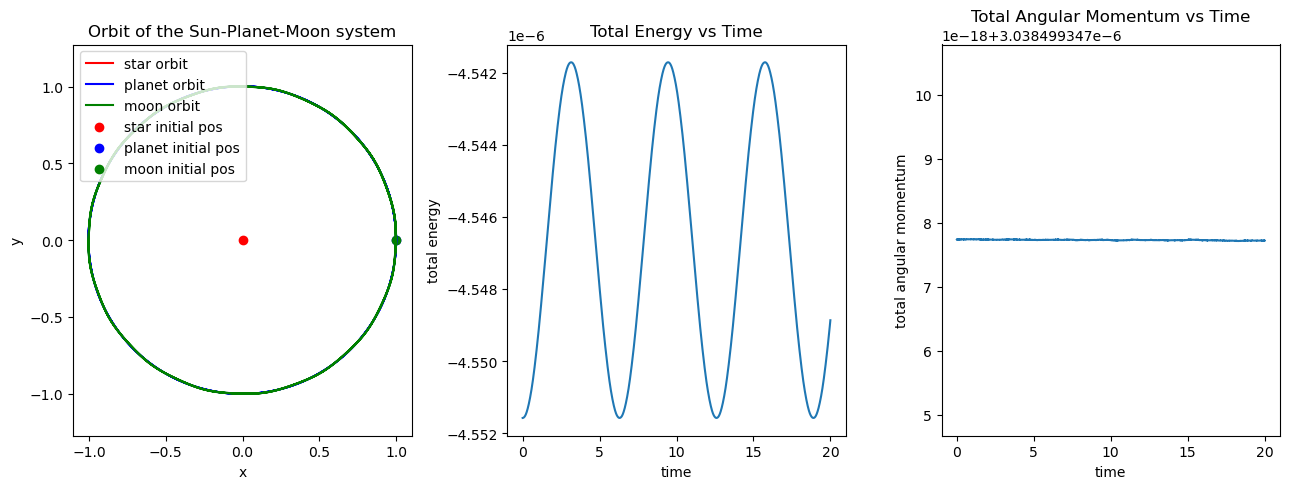

In [56]:
# Plot the orbit (x vs y) and total energy and angular momentum vs time
fig3_verlet = plt.figure(figsize=(13,5),tight_layout=True)
fig3_verlet_1 = fig3_verlet.add_subplot(1,3,1)
fig3_verlet_1.plot(r_star_verlet[:,0], r_star_verlet[:,1], label='star orbit',color='red')
fig3_verlet_1.plot(r_planet_verlet[:,0], r_planet_verlet[:,1], label='planet orbit', color='blue')
fig3_verlet_1.plot(r_moon_verlet[:,0], r_moon_verlet[:,1], label='moon orbit', color='green')
fig3_verlet_1.scatter(x_star_init,[0], color='red', label='star initial pos')
fig3_verlet_1.scatter(x_planet_init,[0], color='blue', label='planet initial pos')
fig3_verlet_1.scatter(x_moon_init,[0], color='green', label='moon initial pos')
fig3_verlet_1.set_xlabel('x')
fig3_verlet_1.set_ylabel('y')
fig3_verlet_1.set_title("Orbit of the Sun-Planet-Moon system")
fig3_verlet_1.axis('equal')
fig3_verlet_1.legend(loc='upper left')

time_verlet = np.arange(Nsteps_verlet)*dt_verlet
fig3_verlet_2 = fig3_verlet.add_subplot(1,3,2)
fig3_verlet_2.plot(time_verlet, total_energy_verlet)
fig3_verlet_2.set_xlabel('time')
fig3_verlet_2.set_ylabel('total energy')
fig3_verlet_2.set_title("Total Energy vs Time")

fig3_verlet_3 = fig3_verlet.add_subplot(1,3,3)
fig3_verlet_3.plot(time_verlet, angular_momentum_verlet)
fig3_verlet_3.set_xlabel('time')
fig3_verlet_3.set_ylabel('total angular momentum')
fig3_verlet_3.set_title("Total Angular Momentum vs Time")

plt.show()

**2025/02/24**: The orbit looks good and total angular momentum is conserved over time. However, we can see *weird little drifts at the peaks and troughs in the total energy curve. I will plot the energies of the three bodies separately to find out why.


***2025/03/02**: At the first attempt I made a mistake in calculating the local velocities of the planet and the moon in the subsystem: I plugged the positions of the two bodies in the whole system (which is supposed to be local positions in the subsystem) into the formula for calculating local velocities. 
 
I spotted this mistake today and found out I made this mistake because I didn't label the local positions of $m2$ and $m3$ as $r_{2local}$ and $r_{3local}$ in the equations above. Instead, I wrote them as $r_2$ and $r_3$ and thus confused myself. 

After fixing this mistake the plots now look expected. The orbit looks good and total angular momentum is pretty conserved over time. We can see peaks and troughs in the total energy curve. Next, I will plot the energies of the three bodies separately,as well as their positions and velocities over time.

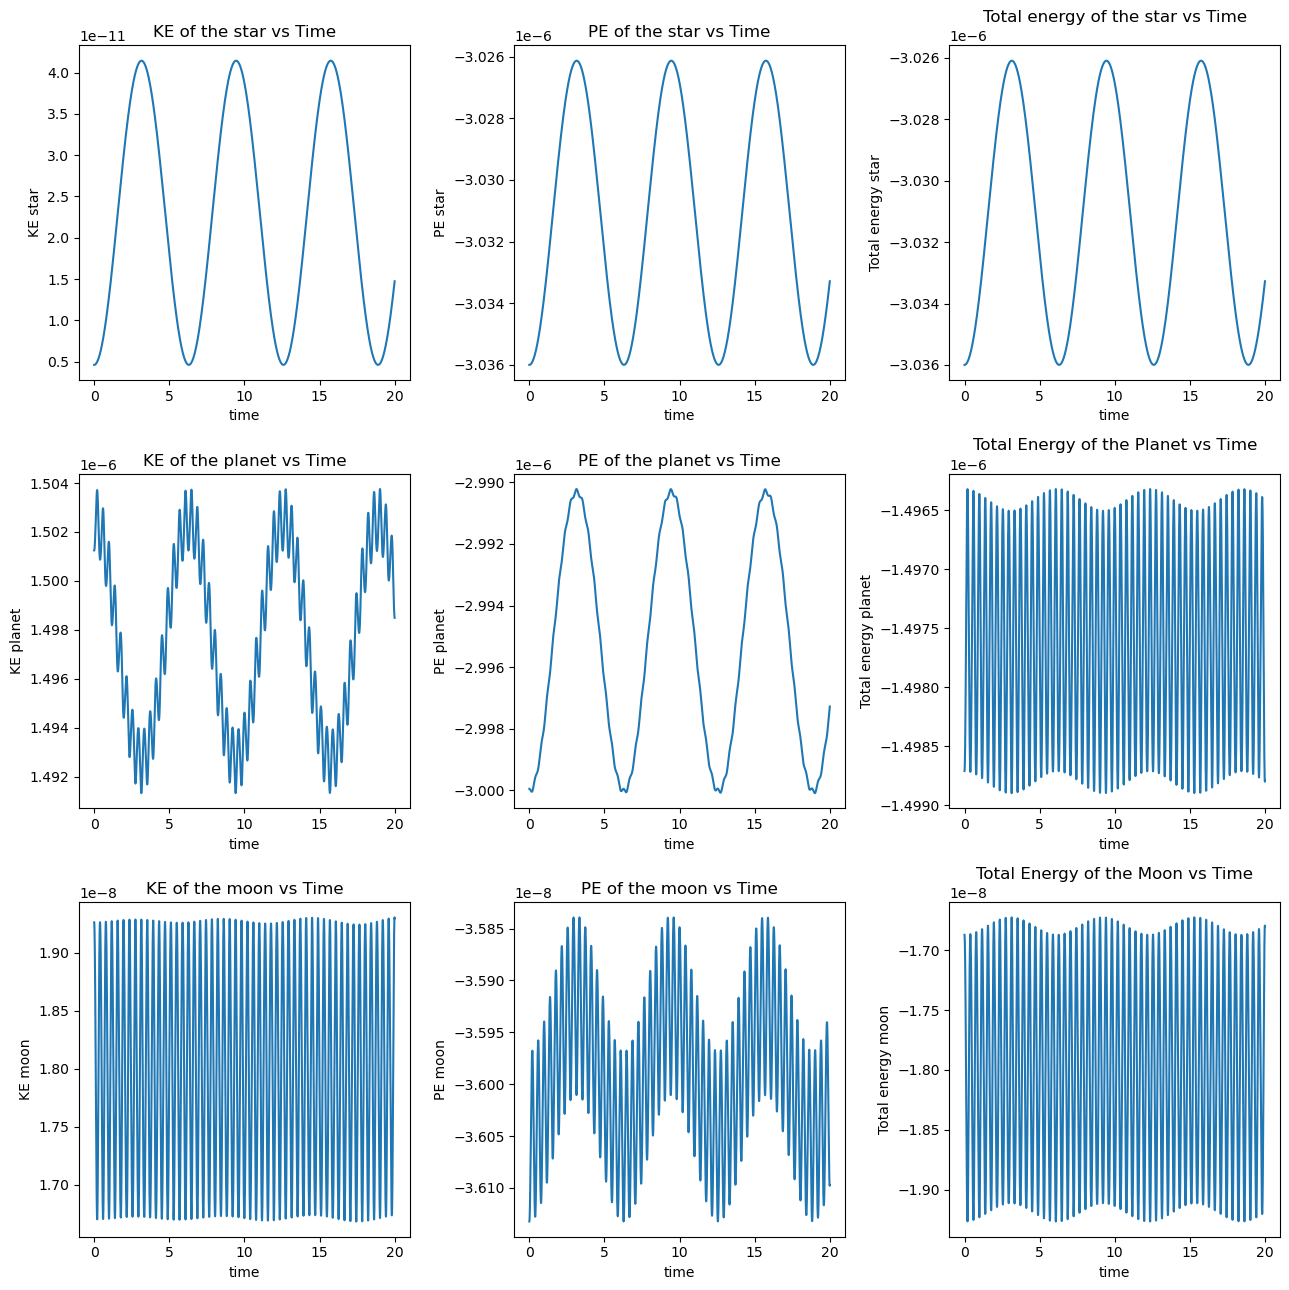

In [58]:
fig4_verlet = plt.figure(figsize=(13,13),tight_layout=True)
fig4_verlet_1 = fig4_verlet.add_subplot(3,3,1)
fig4_verlet_1.plot(time_verlet, KE_star_verlet)
fig4_verlet_1.set_xlabel('time')
fig4_verlet_1.set_ylabel('KE star')
fig4_verlet_1.set_title("KE of the star vs Time")

fig4_verlet_2 = fig4_verlet.add_subplot(3,3,2)
fig4_verlet_2.plot(time_verlet, PE_star_verlet)
fig4_verlet_2.set_xlabel('time')
fig4_verlet_2.set_ylabel('PE star')
fig4_verlet_2.set_title("PE of the star vs Time")

fig4_verlet_3 = fig4_verlet.add_subplot(3,3,3)
fig4_verlet_3.plot(time_verlet, KE_star_verlet+PE_star_verlet)
fig4_verlet_3.set_xlabel('time')
fig4_verlet_3.set_ylabel('Total energy star')
fig4_verlet_3.set_title("Total energy of the star vs Time")

fig4_verlet_4 = fig4_verlet.add_subplot(3,3,4)
fig4_verlet_4.plot(time_verlet, KE_planet_verlet)
fig4_verlet_4.set_xlabel('time')
fig4_verlet_4.set_ylabel('KE planet')
fig4_verlet_4.set_title("KE of the planet vs Time")

fig4_verlet_5 = fig4_verlet.add_subplot(3,3,5)
fig4_verlet_5.plot(time_verlet, PE_planet_verlet)
fig4_verlet_5.set_xlabel('time')
fig4_verlet_5.set_ylabel('PE planet')
fig4_verlet_5.set_title("PE of the planet vs Time")

fig4_verlet_6 = fig4_verlet.add_subplot(3,3,6)
fig4_verlet_6.plot(time_verlet, KE_planet_verlet+PE_planet_verlet)
fig4_verlet_6.set_xlabel('time')
fig4_verlet_6.set_ylabel('Total energy planet')
fig4_verlet_6.set_title("Total Energy of the Planet vs Time")

fig4_verlet_7 = fig4_verlet.add_subplot(3,3,7)
fig4_verlet_7.plot(time_verlet, KE_moon_verlet)
fig4_verlet_7.set_xlabel('time')
fig4_verlet_7.set_ylabel('KE moon')
fig4_verlet_7.set_title("KE of the moon vs Time")

fig4_verlet_8 = fig4_verlet.add_subplot(3,3,8)
fig4_verlet_8.plot(time_verlet, PE_moon_verlet)
fig4_verlet_8.set_xlabel('time')
fig4_verlet_8.set_ylabel('PE moon')
fig4_verlet_8.set_title("PE of the moon vs Time")

fig4_verlet_9 = fig4_verlet.add_subplot(3,3,9)
fig4_verlet_9.plot(time_verlet, KE_moon_verlet+PE_moon_verlet)
fig4_verlet_9.set_xlabel('time')
fig4_verlet_9.set_ylabel('Total energy moon')
fig4_verlet_9.set_title("Total Energy of the Moon vs Time")

plt.show()

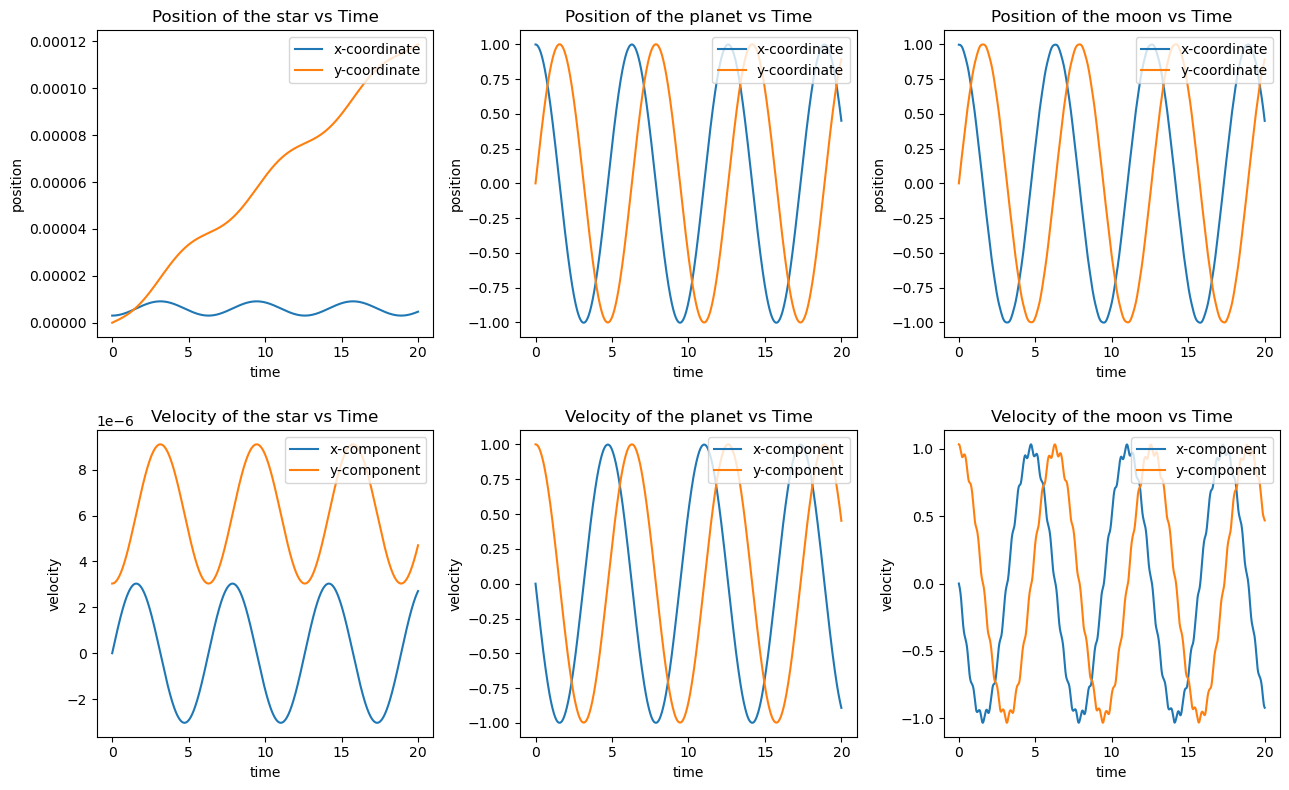

In [59]:
# Plotting the positions and velocities over time
fig5_verlet = plt.figure(figsize=(13,8),tight_layout=True)
fig5_verlet_1 = fig5_verlet.add_subplot(2,3,1)
fig5_verlet_1.plot(time_verlet,r_star_verlet[:,0], label='x-coordinate')
fig5_verlet_1.plot(time_verlet,r_star_verlet[:,1], label='y-coordinate')
fig5_verlet_1.set_xlabel('time')
fig5_verlet_1.set_ylabel('position')
fig5_verlet_1.set_title("Position of the star vs Time")
fig5_verlet_1.legend(loc='upper right')

fig5_verlet_2 = fig5_verlet.add_subplot(2,3,2)
fig5_verlet_2.plot(time_verlet,r_planet_verlet[:,0], label='x-coordinate')
fig5_verlet_2.plot(time_verlet,r_planet_verlet[:,1], label='y-coordinate')
fig5_verlet_2.set_xlabel('time')
fig5_verlet_2.set_ylabel('position')
fig5_verlet_2.set_title("Position of the planet vs Time")
fig5_verlet_2.legend(loc='upper right')

fig5_verlet_3 = fig5_verlet.add_subplot(2,3,3)
fig5_verlet_3.plot(time_verlet,r_moon_verlet[:,0], label='x-coordinate')
fig5_verlet_3.plot(time_verlet,r_moon_verlet[:,1], label='y-coordinate')
fig5_verlet_3.set_xlabel('time')
fig5_verlet_3.set_ylabel('position')
fig5_verlet_3.set_title("Position of the moon vs Time")
fig5_verlet_3.legend(loc='upper right')

fig5_verlet_4 = fig5_verlet.add_subplot(2,3,4)
fig5_verlet_4.plot(time_verlet,v_star_verlet[:,0], label='x-component')
fig5_verlet_4.plot(time_verlet,v_star_verlet[:,1], label='y-component')
fig5_verlet_4.set_xlabel('time')
fig5_verlet_4.set_ylabel('velocity')
fig5_verlet_4.set_title("Velocity of the star vs Time")
fig5_verlet_4.legend(loc='upper right')

fig5_verlet_5 = fig5_verlet.add_subplot(2,3,5)
fig5_verlet_5.plot(time_verlet,v_planet_verlet[:,0], label='x-component')
fig5_verlet_5.plot(time_verlet,v_planet_verlet[:,1], label='y-component')
fig5_verlet_5.set_xlabel('time')
fig5_verlet_5.set_ylabel('velocity')
fig5_verlet_5.set_title("Velocity of the planet vs Time")
fig5_verlet_5.legend(loc='upper right')

fig5_verlet_6 = fig5_verlet.add_subplot(2,3,6)
fig5_verlet_6.plot(time_verlet,v_moon_verlet[:,0], label='x-component')
fig5_verlet_6.plot(time_verlet,v_moon_verlet[:,1], label='y-component')
fig5_verlet_6.set_xlabel('time')
fig5_verlet_6.set_ylabel('velocity')
fig5_verlet_6.set_title("Velocity of the moon vs Time")
fig5_verlet_6.legend(loc='upper right')

plt.show()

Let's zoom in to look at the orbit of the moon around the planet:

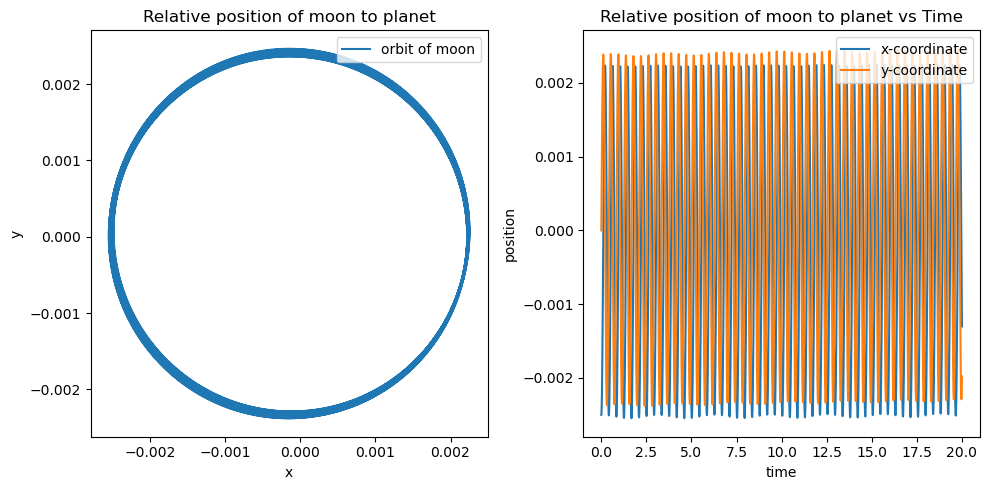

In [61]:
fig6_verlet = plt.figure(figsize=(10,5),tight_layout=True)

fig6_verlet_1 = fig6_verlet.add_subplot(1,2,1)
fig6_verlet_1.plot(r_moon_verlet[:,0]-r_planet_verlet[:,0],r_moon_verlet[:,1]-r_planet_verlet[:,1], label='orbit of moon')
fig6_verlet_1.set_xlabel('x')
fig6_verlet_1.set_ylabel('y')
fig6_verlet_1.set_title("Relative position of moon to planet")
fig6_verlet_1.legend(loc='upper right')

fig6_verlet_2 = fig6_verlet.add_subplot(1,2,2)
fig6_verlet_2.plot(time_verlet,r_moon_verlet[:,0]-r_planet_verlet[:,0], label='x-coordinate')
fig6_verlet_2.plot(time_verlet,r_moon_verlet[:,1]-r_planet_verlet[:,1], label='y-coordinate')
fig6_verlet_2.set_xlabel('time')
fig6_verlet_2.set_ylabel('position')
fig6_verlet_2.set_title("Relative position of moon to planet vs Time")
fig6_verlet_2.legend(loc='upper right')
plt.show()

We can see the tidal effects in the orbit, which implies that the orbit is simulated accurately.

## 4. Simulating Orbits using Runge-Kutta integrator

**2025/03/15**

Now we are going to evolve the gravitational systems using a higher order integrator: **the fourth order Runge-Kutta integrator**.


Runge-Kutta method is one of the methods that improve on the stability and accuracy of Euler's method. It uses intermediate gradients to improve the accuracy in sub-divisions, and are named by the order of accuracy that they achieve. The fourth-order Runge-Kutta integrator (which we are going to use) is most commonly used: it is fourth order in accuracy $(\Delta x^4)$ but it requires *four* function evaluations. 

The update scheme can be written as:

$$y(x+\Delta x) = y(x)+\frac{1}{6}(k_1 +2k_2 +2k_3+k_4)$$
$$k_1 = \Delta x f (x,y(x))$$
$$k_2 = \Delta x f(x+\Delta x/2, y(x)+k_1/2)$$
$$k_3 = \Delta x f(x+\Delta x/2, y(x) +k_2/2)$$
$$k_4 = \Delta xf(x+\Delta x,y(x)+k_3))$$

We can make a closer link to the arrays used in typical Python implementations if we write the update as follows:

$$y_{n+1} = y_n+\frac{1}{6}(k_1 +2k_2 +2k_3+k_4)$$
$$k_1 = \Delta x f (x_n,y_n)$$
$$k_2 = \Delta x f(x_n+\Delta x/2, y_n+k_1/2)$$
$$k_3 = \Delta x f(x_n+\Delta x/2, y_n +k_2/2)$$
$$k_4 = \Delta xf(x_n+\Delta x,y_n+k_3))$$

where $k_1$ is the same as the Euler update, $k_2$ and $k_3$ are mid-point evaluations, and $k_4$ is an end-point. By combining these, we can eliminate eroors below fourth order.

Computationally, the function $f(x,y)$ is a *continuous* function (i.e. it is a standard function that we define which takes any values of $x$ and $y$ while $x_n$ and $y_n$ are entries in arrays. This means that we need to pack the positions and velocities of each body into one array to put into the RK4 algorithm. To achieve this we need to break the second-order equation of motion into two coupled first-order equations:

$$ \frac{d^2x}{dt^2} = \frac{F}{m}$$

is decoupled into:

$$ \frac{dv}{dt} = \frac{F}{m}$$ and $$\frac{dx}{dt} = v$$


(The `RK4_solver` function is taken from session 4 notes$^{[1]}$.)

In [65]:
# Define a function that runs the RK4 algorithm
def RK4_solver(fun,x0,dt,N):
    """Solve dx/dt = fun(x,t) using fourth-order RK method.
    Inputs:
    - fun  f(x,t)
    - x0   Initial condition 
    - dt   Step size
    - N    Number of steps
    Output: 
    4 arrays of length N+1 
    """
    # Storage for solution
    x_n = np.zeros((N+1,4))
    # Initial condition
    x_n[0] = x0
    t = 0
    for i in range(N):
        # RK4 formulae
        k1 = dt*fun(x_n[i],t)
        k2 = dt*fun(x_n[i]+0.5*k1,t+0.5*dt)
        k3 = dt*fun(x_n[i]+0.5*k2,t+0.5*dt)
        k4 = dt*fun(x_n[i]+k3,t+dt)
        x_n[i+1]=x_n[i]+(k1+2*k2+2*k3+k4)/6
        t += dt
    return x_n

### A small mass orbiting a fixed large mass
We will try the RK4 with the simplest system: a small mass orbiting a fixed large mass.

In [67]:
# Initial parameters
G = 1.0
m_small_RK4 = 0.0001
m_large_RK4 = 1.0
rx_small_RK4 = 1.0
ry_small_RK4 = 0.0
r_small_RK4 = np.array([rx_small_RK4,ry_small_RK4])
vx_small_RK4 = 0.0
vy_small_RK4 = 1.0
v_small_RK4 = np.array([vx_small_RK4,vy_small_RK4])
rx_large_RK4 = 0.0
ry_large_RK4 = 0.0
r_large_RK4 = np.array([rx_large_RK4,ry_large_RK4])

In [69]:
def RHS_motion_equation(x,t):
    """Implements linear equation of motion RHS for ODE solver
    
    Inputs:
    - x_n   2D vector containing position r and velocity v of a body
    - t     Time (unused)
    
    Output:
    dx_n  4D vector containing gradients dr and dv
    """
    # Separate for clarity
    rx,ry,vx,vy = x
    drx = vx
    dry = vy
    rxy = np.array([rx,ry])
    F = force(rxy,r_large_RK4,m_small_RK4, m_large_RK4)
    dvx, dvy = F/m_small_RK4
    return np.array([vx,vy,dvx,dvy])

**2025/03/15**: I had a few failed attempts with the RK4 integrator. The first mistake I made was with the `RHS_motion_equation` function. I called the force function separately for the x-components and y‐components using scalar values. This decouples the coordinates and leads to the orbit plot being a straight‐line rather than a circular orbit.

The second mistake was also with the `RHS_motion_equation` function, where I did not use the updated positions to calculate $F$. Instead, I was always using the global variable `r_small_RK4` which is fixed at $(1,0)$. Therefore after fixing the first mistake, I got orbit plots that are no longer straight lines, but still far from being circular.

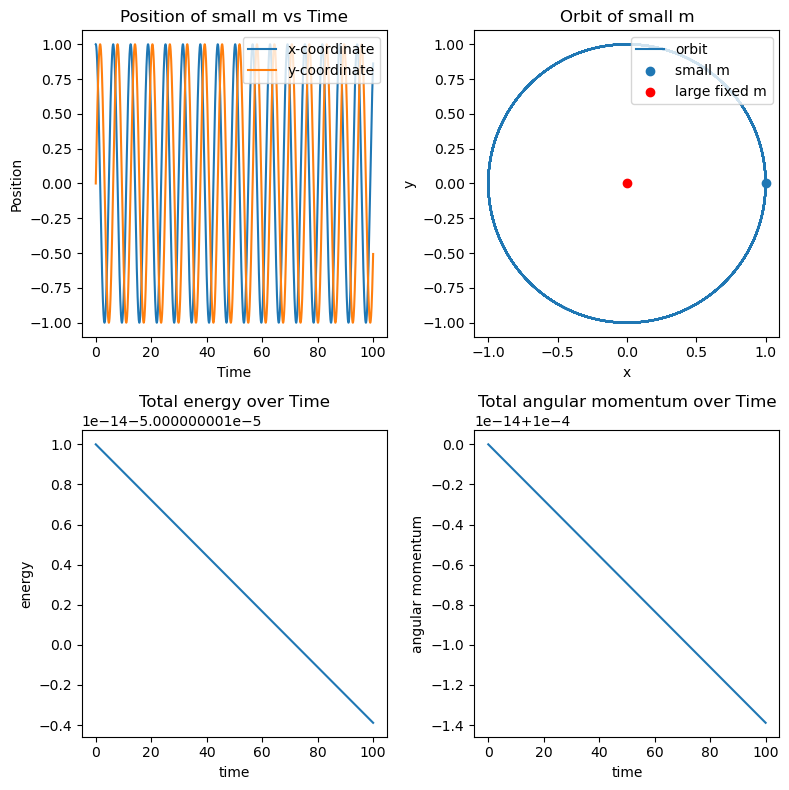

In [71]:
dt = 0.01
total_t = 100
N = int(total_t/dt)
# Initial conditions: position (1.0,0.0) and velocity (0.0,1.0) packed into a single array
x0 = np.array([rx_small_RK4,ry_small_RK4,vx_small_RK4,vy_small_RK4])
RK4_sol = RK4_solver(RHS_motion_equation,x0,dt,N)
t = np.linspace(0,total_t,N+1)
rx_new = RK4_sol[:,0]
ry_new = RK4_sol[:,1]
vx_new = RK4_sol[:,2]
vy_new = RK4_sol[:,3]

rxy_new = np.array([rx_new,ry_new])
vxy_new = np.array([vx_new,vy_new])

# Compute the energies and angular momentum for m1.
KE_RK4 = 0.5*m_small_RK4*(vx_new**2+vy_new**2)
distance = np.sqrt(rx_new**2 + ry_new**2)
PE_RK4 = -G*m_small_RK4*m_large_RK4 / distance
total_energy_RK4 = KE_RK4 + PE_RK4
# Angular momentum in 2D: L = m_small * (x*v_y - y*v_x)
angular_momentum_RK4 = m_small_RK4*(rx_new*vy_new - ry_new*vx_new)

fig1_RK4 = plt.figure(figsize=(8,8),tight_layout=True)
fig1_RK4_1 = fig1_RK4.add_subplot(2,2,1)
fig1_RK4_1.plot(t,rx_new,label='x-coordinate')
fig1_RK4_1.plot(t,ry_new,label='y-coordinate')
fig1_RK4_1.set_xlabel("Time")
fig1_RK4_1.set_ylabel("Position")
fig1_RK4_1.set_title("Position of small m vs Time")
fig1_RK4_1.legend(loc='upper right')

fig1_RK4_2 = fig1_RK4.add_subplot(2,2,2)
fig1_RK4_2.plot(rx_new,ry_new,label='orbit')
fig1_RK4_2.scatter(rx_small_RK4,ry_small_RK4,label='small m')
fig1_RK4_2.scatter([0],[0],label='large fixed m',color='red')
fig1_RK4_2.set_xlabel("x")
fig1_RK4_2.set_ylabel("y")
fig1_RK4_2.set_title("Orbit of small m")
fig1_RK4_2.legend(loc='upper right')

fig1_RK4_3 = fig1_RK4.add_subplot(2,2,3)
fig1_RK4_3.plot(t,total_energy_RK4)
fig1_RK4_3.set_xlabel("time")
fig1_RK4_3.set_ylabel("energy")
fig1_RK4_3.set_title("Total energy over Time")

fig1_RK4_4 = fig1_RK4.add_subplot(2,2,4)
fig1_RK4_4.plot(t,angular_momentum_RK4)
fig1_RK4_4.set_xlabel("time")
fig1_RK4_4.set_ylabel("angular momentum")
fig1_RK4_4.set_title("Total angular momentum over Time")

plt.show()

After fixing the mistakes I made with the functions, the plots look very much like what we would expect from using a RK4 integrator:
- stable orbit that remains a nearly perfect circular shapes for many periods
- a steady drift in both energy and angular momentum (expected behavior for a non‐symplectic method like RK4 when used on orbital problems over many orbits)

**2025/03/17**: Experiment the RK4 integrator method with different values for $dt$

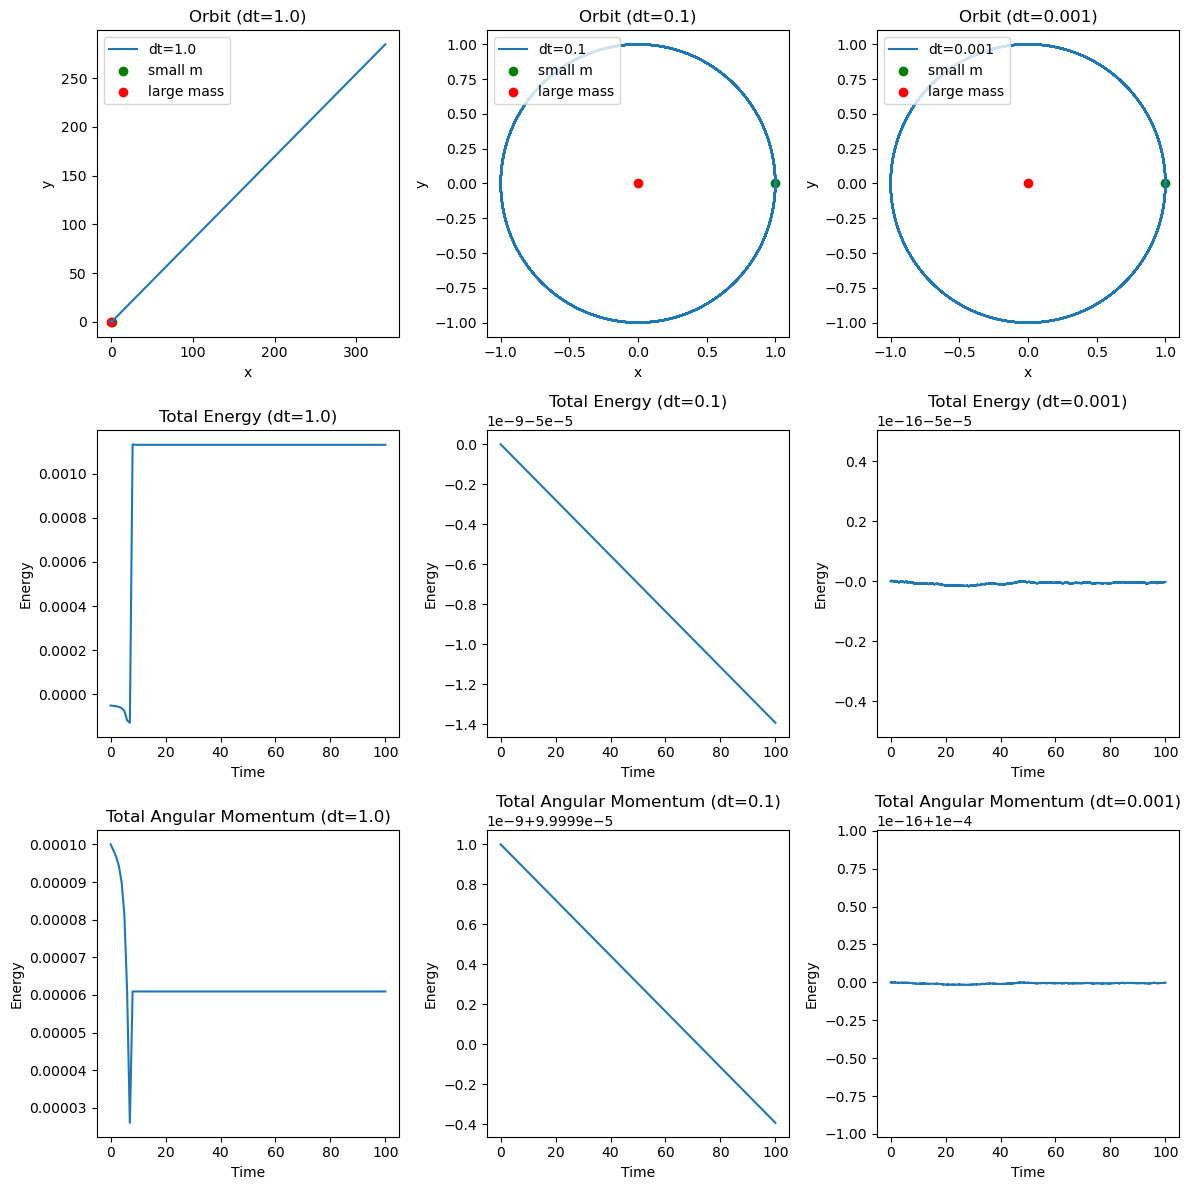

In [74]:
# Experiment with different values for dt
dt_values = [1.0,0.1,0.001]
total_t = 100

# Prepare subplots: one row for orbits, one row for total energies, one row for total angular momentum
fig, axes = plt.subplots(3,len(dt_values),figsize=(12,12),tight_layout=True)
for i, dt in enumerate(dt_values):
    N = int(total_t / dt)
    RK4sol = RK4_solver(RHS_motion_equation,x0,dt,N)
    t = np.linspace(0,total_t,N+1)
    rx_new = RK4sol[:,0]
    ry_new = RK4sol[:,1]
    vx_new = RK4sol[:,2]
    vy_new = RK4sol[:,3]

    rxy_new = np.array([rx_new,ry_new])
    vxy_new = np.array([vx_new,vy_new])

    # Compute the energies and angular momentum for m1.
    KE_RK4 = 0.5*m_small_RK4*(vx_new**2+vy_new**2)
    distance = np.sqrt(rx_new**2 + ry_new**2)
    PE_RK4 = -G*m_small_RK4*m_large_RK4 / distance
    total_energy_RK4 = KE_RK4 + PE_RK4
    # Angular momentum L = m_small * (x*v_y - y*v_x)
    angular_momentum_RK4 = m_small_RK4*(rx_new*vy_new - ry_new*vx_new)

    # Plot orbits, energies and angular momentum
    axes[0,i].plot(rx_new, ry_new,label=f"dt={dt}")
    axes[0,i].scatter([x0[0]], [x0[1]], color='green', label='small m')
    axes[0,i].scatter([0],[0], color='red', label='large mass')
    axes[0,i].set_title(f"Orbit (dt={dt})")
    axes[0,i].set_xlabel("x")
    axes[0,i].set_ylabel("y")
    axes[0,i].legend(loc='upper left')

    axes[1,i].plot(t, total_energy_RK4)
    axes[1,i].set_title(f"Total Energy (dt={dt})")
    axes[1,i].set_xlabel("Time")
    axes[1,i].set_ylabel("Energy")
   
    axes[2,i].plot(t, angular_momentum_RK4)
    axes[2,i].set_title(f"Total Angular Momentum (dt={dt})")
    axes[2,i].set_xlabel("Time")
    axes[2,i].set_ylabel("Energy")
    

plt.show()

The plots look exactly as we would expect from RK4 with different timesteps:
1. $dt = 1.0$ : Time step is far too large for stable orbital motion. The small mass flies off in a nearly straight line. We can see the energy and angular momentum blow up or behave strangely almost immediately.
2. $dt = 0.1$ : More stable orbit than with $dt=1.0$. However, there are still energy drift and angular momentum drift (non-symplectic integrator effect).
3. $dt = 0.001$ : Much more accurate orbit that remains circular for many periods. Energy and angular momentum are significantly better conserved, though there might still be a slow drift if we run for a very long time.

### Conclusion on the Fourth Order Runge-Kutta integrator
RK4 is able to achieve high degree of accuracy and conservation of Hamiltonian quantities in orbit simulations, only with a sufficiently small timestep. However it requires more computational time when compared at the same timestep. This is because RK4 evaluates the derivative four times per step (through its $k_1$,$k_2$,$k_3$ and $k_4$ calculations), whereas the velocity Verlet method requires only two evaluations per timestep. Therefore we can conlcude that the velocity Verlet integrator would be the most suitable for more complex orbit simulations in our extension investigation.

## Conclusion 
Throughout this logbook, we explored the application of a range of computational physics techniques to gravitational systems - from basic integration methods to three-body dynamics. 

We began by implementing and comparing Euler’s method, the velocity Verlet integrator, and the fourth-order Runge–Kutta method to solve simple orbital motions. Through these exercises, we gained insight into behaviours of stable two-body and star-planet-moon systems. We also investigated on timestep sensitivity and conservation of energy and angular momentum.

Building on this foundation, we will extended our investigation by simulating more three-body choreographies. The extension work is done in logbook 2.

### References:
[1]: Bowler. D, Korn. A. PHAS0030: Computational Physics Session 4: Ordinary Differential Equations. Department of Physics and Astronomy, University College London, February 2025.